# Notatki

In [1]:
from dislocations import *

# Eksperymenty

### Konfiguracja pierwotna

Tworzymy strukturę przechowującą siatkę krystalograficzną.

Text(0.5, 1.0, 'Initial configuration')

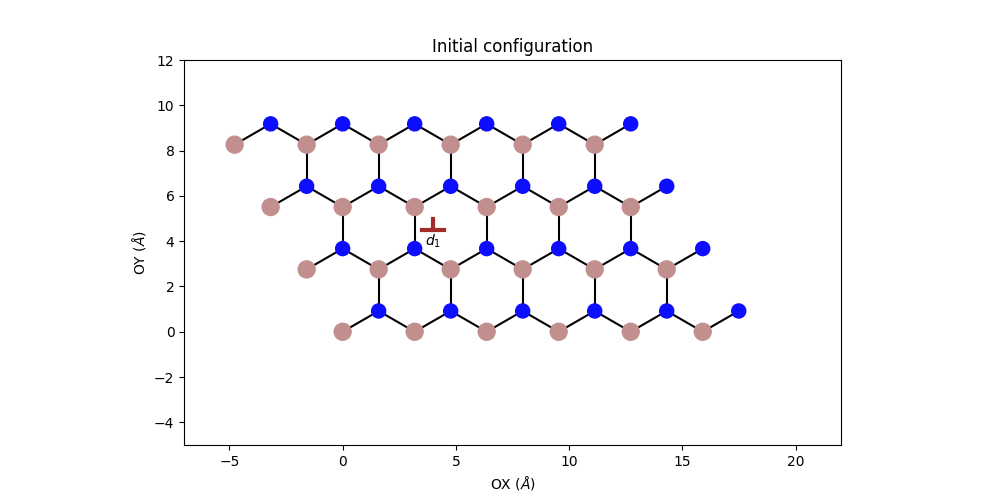

In [2]:
l0 = wzt.generate.create_lattice(
    dimensions=(6, 4, 1),  # (nx, ny, nz)
    cell="B4_GaN",
)


d1 = wzt.model.DislocationDef(
    # Wektor burgersa
    b=[1, 0, 0],
    # Położenie rdzenia dyslokacji
    position=[3.190+0.8+0*l0.cell.dimensions[0], 4.5, 7.5],
    # position=[4.01, 3.17, 7.5],
    # Płaszczyzna
    plane=(0, 0, 1),
    # Etykieta (tylko do prezentacji)
    label="$d_1$",
    # Kolor (tylko do prezentacji)
    color="brown"
)

%matplotlib widget
fig, ax = wzt.visualization.plot_atoms_2d(l0, xlim=(-7, 22), ylim=(-5, 12), figsize=(10, 5))
wzt.visualization.display_tee_2d(ax, d1, scale=0.5)
ax.set_title("Initial configuration")

### Pierwsza dyslokacja

[[-1.10571605e+00 -1.42676085e-02  5.56275000e+00]
 [-1.06631835e+00  5.09482957e-02  4.91700000e+00]
 [-9.36254082e-01  1.86535927e-01  5.56275000e+00]
 [-8.82837406e-01  2.74539805e-01  4.91700000e+00]
 [-8.30858732e-01  1.97520050e-01  5.56275000e+00]
 [-7.06195265e-01  6.39473847e-02  4.91700000e+00]
 [-6.63368605e-01 -6.64818240e-03  5.56275000e+00]
 [-5.19945761e-01 -1.07811850e-01  4.91700000e+00]
 [-5.19831234e-01 -1.32743797e-01  5.56275000e+00]
 [-4.08477840e-01 -1.91903844e-01  4.91700000e+00]
 [-4.25293375e-01 -2.04144291e-01  5.56275000e+00]
 [-3.39859173e-01 -2.42219507e-01  4.91700000e+00]
 [-1.41821781e+00 -1.65335503e-01  5.56275000e+00]
 [-1.48340846e+00 -1.49907229e-01  4.91700000e+00]
 [-1.25705676e+00 -4.38847384e-02  5.56275000e+00]
 [-1.28300887e+00  1.01710593e-02  4.91700000e+00]
 [-8.87141790e-01  3.63405272e-01  5.56275000e+00]
 [-5.04168298e-01  3.25648910e-02  4.91700000e+00]
 [-5.18258479e-01 -3.25481774e-02  5.56275000e+00]
 [-2.81612223e-01 -1.47219968e-

Text(0.5, 1.0, 'Current configuration (1st dislocation)')

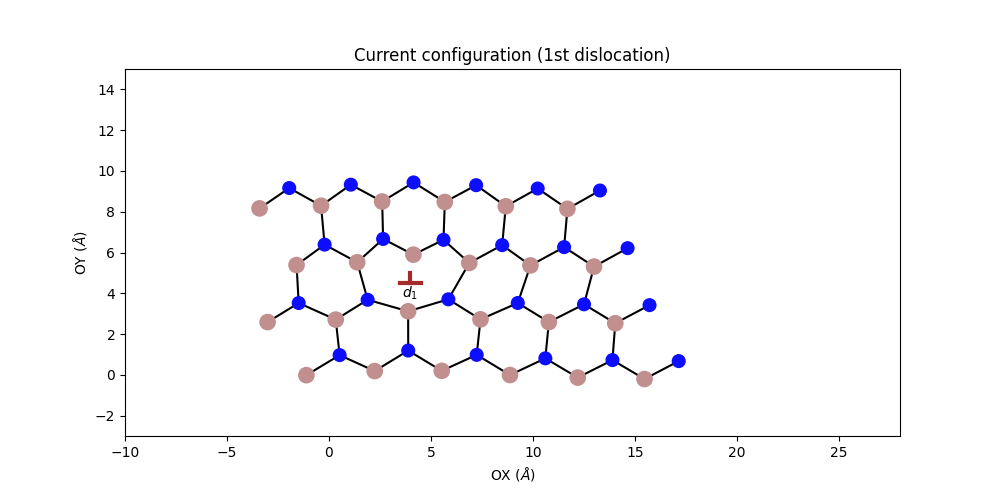

In [3]:
log = displace(
    crystal=l0,
    dislocations=[], # No dislocations
    d_n=d1,
    n_iters=1
)

u0 = log.last_u_atoms

print(u0)


# Przesuń atomy
l1 = l0.translate(u0)
# Zaktualizuj wiązania
l1 = wzt.generate.update_bonds(l1, tolerance=0.45)

# # Wyswietl nowa siatke
%matplotlib widget
fig, ax = wzt.visualization.plot_atoms_2d(l1, xlim=(-10, 28), ylim=(-3, 15), figsize=(10, 5))
# Wyswietl teownik
wzt.visualization.display_tee_2d(ax, d1, scale=0.5)
ax.set_title("Current configuration (1st dislocation)")